# Notebook Overview

This Notebook attempts to scale the labels/expense which might have caused the explosion in gradient and failed

# Conclusion

The model has learned the overall linear trend of the data, but it hasn't been able to bend to capture the non-linear curves between columns like smoker and BMI interactions. To fix this non linear activations such as relu should be introduced

In [1]:
# Import libraries. You may or may not use all of these.
!pip install -q git+https://github.com/tensorflow/docs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
  # %tensorflow_version only exists in Colab.
  %tensorflow_version 2.x
except Exception:
  pass
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras.layers import Dense

import tensorflow_docs as tfdocs
import tensorflow_docs.plots
import tensorflow_docs.modeling

  Preparing metadata (setup.py) ... done
Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


In [7]:
# Import data
!wget https://cdn.freecodecamp.org/project-data/health-costs/insurance.csv
dataset = pd.read_csv('insurance.csv')


--2026-05-25 17:45:33--  https://cdn.freecodecamp.org/project-data/health-costs/insurance.csv
Resolving cdn.freecodecamp.org (cdn.freecodecamp.org)... 104.26.3.33, 172.67.70.149, 104.26.2.33, ...
Connecting to cdn.freecodecamp.org (cdn.freecodecamp.org)|104.26.3.33|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 50264 (49K) [text/csv]
Saving to: ‘insurance.csv.1’

insurance.csv.1     100%[===================>]  49.09K  --.-KB/s    in 0.001s  

2026-05-25 17:45:33 (44.2 MB/s) - ‘insurance.csv.1’ saved [50264/50264]



In [3]:
dataset.tail()

,age,sex,bmi,children,smoker,region,expenses
1333,50,male,31.0,3,no,northwest,10600.55
1334,18,female,31.9,0,no,northeast,2205.98
1335,18,female,36.9,0,no,southeast,1629.83
1336,21,female,25.8,0,no,southwest,2007.95
1337,61,female,29.1,0,yes,northwest,29141.36


In [4]:
# size of dataset
dataset.shape

(1338, 7)

In [5]:
# investigating for null values

dataset.isna().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
expenses,0


In [9]:
labels = dataset.pop("expenses")

In [11]:
max = labels.max()

In [12]:
# normalizing labels
labels = labels / labels.max()

In [13]:
# unique regions
dataset['region'].nunique()

4

In [14]:
dataset.head()

,age,sex,bmi,children,smoker,region
0,19,female,27.9,0,yes,southwest
1,18,male,33.8,1,no,southeast
2,28,male,33.0,3,no,southeast
3,33,male,22.7,0,no,northwest
4,32,male,28.9,0,no,northwest


In [15]:
# converting categorical columns to onehot encode

categorical = ["sex","smoker","region"]
# drop first column for statistical significance

dataset = pd.get_dummies(dataset, columns = categorical, drop_first = True,dtype =int)

In [16]:
dataset.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.9,0,0,1,0,0,1
1,18,33.8,1,1,0,0,1,0
2,28,33.0,3,1,0,0,1,0
3,33,22.7,0,1,0,1,0,0
4,32,28.9,0,1,0,1,0,0


In [17]:
# normalizing data

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
dataset[["age","bmi","children"]] = scaler.fit_transform(dataset[["age","bmi","children"]])

In [18]:
dataset[['age','bmi','children']] # standardized

,age,bmi,children
0,-1.438764,-0.453646,-0.908614
1,-1.509965,0.514186,-0.078767
2,-0.797954,0.382954,1.580926
3,-0.441948,-1.306650,-0.908614
4,-0.513149,-0.289606,-0.908614
...,...,...,...
1333,0.768473,0.054876,1.580926
1334,-1.509965,0.202511,-0.908614
1335,-1.509965,1.022707,-0.908614
1336,-1.296362,-0.798128,-0.908614


In [19]:
X = dataset.values
Y = labels.values

In [20]:
# split and shuffle
from sklearn.model_selection import train_test_split

train_dataset,test_dataset,train_labels,test_labels = train_test_split(X,Y,test_size = 0.2,random_state = 42)

In [21]:
test_labels.shape

(268,)

In [22]:
train_dataset.shape

(1070, 8)

In [24]:
# model creation

from keras import Sequential
from keras.layers import Input
from keras.layers import Dense

model = Sequential()
model.add(Input(shape = (train_dataset.shape[1],)))
model.add(Dense(1, activation= 'linear'))

In [25]:
# compile model

model.compile(optimizer='adam',loss = 'mse',metrics = ['mae', 'mse'])

In [26]:
'''
fitting model
converting the categorical columns to floats as they are currently bools
'''
model.fit(train_dataset,train_labels,epochs = 100,batch_size =32)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.3216 - mae: 0.9208 - mse: 1.3216
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.1607 - mae: 0.8620 - mse: 1.1607
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0182 - mae: 0.8091 - mse: 1.0182
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8985 - mae: 0.7604 - mse: 0.8985
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7936 - mae: 0.7154 - mse: 0.7936
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7025 - mae: 0.6739 - mse: 0.7025
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6223 - mae: 0.6346 - mse: 0.6223
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5523 - mae: 0.5984 - mse: 0.5523
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4884 - mae: 0.5645 - mse: 0.4884
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4333 - mae: 0.5318 - mse: 0.4333
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss:

In [28]:
scaled_predictions = model.predict(test_dataset).flatten()
y_pred = scaled_predictions * max

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [29]:
targets = test_labels * max

In [30]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(targets,y_pred)

4161.52328641977

In [34]:
mean_absolute_error(test_labels,scaled_predictions)

0.06525788348925393

9/9 - 0s - 7ms/step - loss: 0.0083 - mae: 0.0653 - mse: 0.0083
0.06525788456201553
Testing set Mean Abs Error:  0.07 expenses
The Mean Abs Error must be less than 3500. Keep trying.
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


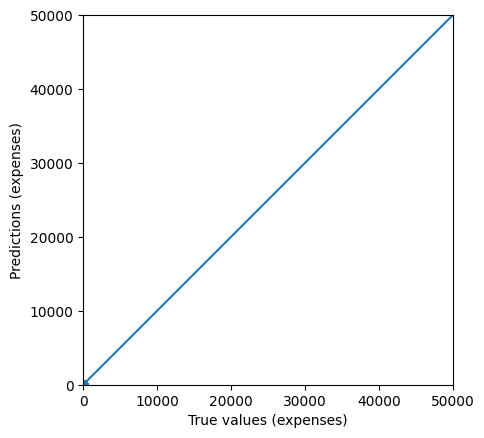

In [35]:
# RUN THIS CELL TO TEST YOUR MODEL. DO NOT MODIFY CONTENTS.
# Test model by checking how well the model generalizes using the test set.
loss, mae, mse = model.evaluate(test_dataset, test_labels, verbose=2)
print(mae)
print("Testing set Mean Abs Error: {:5.2f} expenses".format(mae))

if mae < 3500/max:
  print("You passed the challenge. Great job!")
else:
  print("The Mean Abs Error must be less than 3500. Keep trying.")

# Plot predictions.
test_predictions = model.predict(test_dataset).flatten()

a = plt.axes(aspect='equal')
plt.scatter(test_labels, test_predictions)
plt.xlabel('True values (expenses)')
plt.ylabel('Predictions (expenses)')
lims = [0, 50000]
plt.xlim(lims)
plt.ylim(lims)
_ = plt.plot(lims,lims)
